In [1]:
import ast
import os
import pandas as pd

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_data = f'{base_folder}/figure_data'
os.makedirs(figure_data, exist_ok=True)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Rectangle

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()

plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

italic_font = FontProperties(fname=ifont_path)
normal_font = FontProperties(fname=font_path)
legend_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=8)

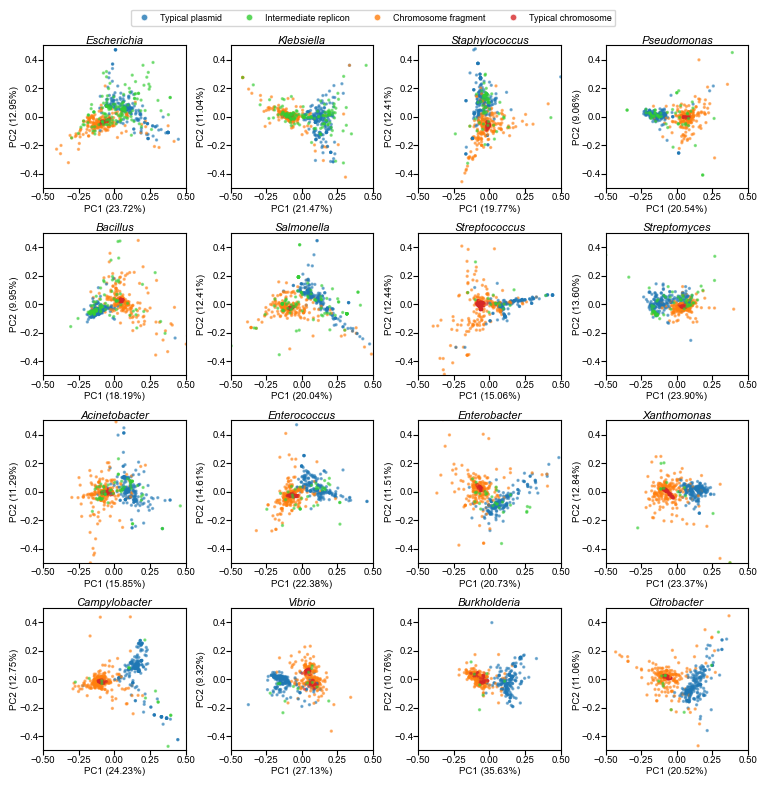

In [3]:
import numpy as np
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def draw_scatter_plot(ax, pca_result_df, explained_variance, genus_name):
    inter_result = pca_result_df[pca_result_df[group_col]=='intermediate replicon']
    rest_result = pca_result_df[pca_result_df[group_col]!='intermediate replicon']
    
    ax.scatter(rest_result["PC1"], rest_result["PC2"], c=rest_result["point_color"], alpha=0.5, s=2)
    ax.scatter(inter_result["PC1"], inter_result["PC2"], c=inter_result["point_color"], alpha=0.5, s=2)
    
    ax.set_xlabel(f"PC1 ({explained_variance[0]:.2%})", labelpad=2)
    ax.set_ylabel(f"PC2 ({explained_variance[1]:.2%})", labelpad=0)
    ax.set_title(f"{genus_name}", fontproperties=title_font, pad=1)
    ax.set_xlim(-0.5,0.5)
    ax.set_ylim(-0.5,0.5)
    
    ax.tick_params(axis='x', pad=0)
    ax.tick_params(axis='y', pad=0)

fig = plt.figure(figsize=(7.5, 7.5))
gap = 0.06
split_size = 1/4
length = split_size - gap

all_category_labels = ['typical plasmid', 'intermediate replicon', 'chromosome fragment', 'typical chromosome']
color_map = [plt.cm.tab10(0), "#32CD32", plt.cm.tab10(1), plt.cm.tab10(3)]
color_dict = {cat: color_map[idx] for idx, cat in enumerate(all_category_labels)}

i = 0
for genus_name in keep_genus:
    replicon_data = pd.read_csv(f'{base_folder}/statistics_records/{genus_name}/replicon-plasmid_fraction-self_bitscore_statistics.csv')
    cog_data = pd.read_csv(f'{base_folder}/statistics_records/{genus_name}/COG_statistics.tsv', sep='\t')
    cog_data = pd.merge(cog_data, replicon_data[['accession', 'category-pident_90']], on='accession', how='left')
    cog_data.rename(columns={'accession': 'sequence'}, inplace=True)
    
    cog_data_chr_frag = pd.read_csv(f'{base_folder}/kmer_chr_frag_samples/{genus_name}/COG_statistics.tsv', sep='\t')
    cog_data_chr_frag['category-pident_90'] = 'chromosome fragment'
    
    all_cog_data = pd.concat([cog_data, cog_data_chr_frag], ignore_index=True)
    
    cog_letter_cols = ['J', 'A', 'K', 'L', 'B', 'D', 'Y', 'V', 'T', 'M', 'N', 'Z', 'W', 'U', 'O', 'X', 'C', 'G', 'E', 'F', 'H', 'I', 'P', 'Q', 'R', 'S']
    total_cds_col = "All coding CDSs"
    group_col = "category-pident_90"
    
    ratio_df = all_cog_data[["sequence", total_cds_col, group_col]].copy()
    for col in cog_letter_cols:
        ratio_df[f"{col}_ratio"] = all_cog_data[col] / all_cog_data[total_cds_col].replace(0, np.nan)
    
    ratio_df = ratio_df.dropna(subset=[f"{c}_ratio" for c in cog_letter_cols])
    
    sample_list = []
    group_names = ratio_df[group_col].unique()
    
    for group in group_names:
        group_sub = ratio_df[ratio_df[group_col] == group]
        if len(group_sub) > 200:
            sample_sub = group_sub.sample(n=200, replace=False, random_state=RANDOM_SEED)
        else:
            sample_sub = group_sub.copy()
        sample_list.append(sample_sub)
    
    sampled_df = pd.concat(sample_list, axis=0).reset_index(drop=True)
    if 'intermediate replicon' not in sampled_df[group_col].value_counts().index:
        continue
    elif sampled_df[group_col].value_counts()['intermediate replicon'] < 5:
        continue
    
    pca_feature_cols = [f"{c}_ratio" for c in cog_letter_cols]
    X_raw = sampled_df[pca_feature_cols].values
    
    pca = PCA()
    X_pca = pca.fit_transform(X_raw)
    
    pca_result_df = pd.DataFrame(
        data=X_pca,
        columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
    )
    
    pca_result_df = pd.concat([
        sampled_df[["sequence", group_col]].reset_index(drop=True),
        pca_result_df
    ], axis=1)
    pca_result_df["point_color"] = pca_result_df[group_col].map(color_dict)
    pca_result_df = pca_result_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    
    explained_variance = pca.explained_variance_ratio_

    ax = fig.add_axes([gap+split_size*(i%4), 1-length-split_size*int(i/4), length, length])
    draw_scatter_plot(ax, pca_result_df, explained_variance, genus_name)
    i+=1

legend_elements = []
for label, color in color_dict.items():
    legend_elements.append(Line2D([], [], marker='o', color='w', markerfacecolor=color, markersize=5, alpha=0.8, label=label.capitalize(), linestyle=''))

fig.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=len(legend_elements))

figure_fold = '/active-data/analysis_results/chr_pla/genus/figures/scatter_plot'
os.makedirs(figure_fold, exist_ok=True)
os.chdir(figure_fold)
plt.savefig("S_COG_PCA.svg", bbox_inches="tight", transparent=True)
plt.savefig("S_COG_PCA.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()